# United States Top 50 Playlist Performance & Song Popularity Trend Analysis
### Atlantic Recording Corporation — Historical Playlist Analytics

**Background:** Music consumption in the streaming era is highly dynamic — song popularity changes daily, playlist rankings directly influence streams and revenue, and artist visibility depends on chart persistence, not just peak rank. For a label like Atlantic, understanding playlist behavior over time informs artist promotion strategy, release timing, marketing spend, and catalog performance.

**Scope:** This notebook covers the full analytical methodology end-to-end:

1. Data Ingestion & Validation
2. Feature Engineering
3. Playlist Ranking Analysis
4. Song-Level Performance Analysis
5. Artist Performance Analysis
6. Popularity Score Analytics
7. Content Attribute Analysis
8. Machine Learning (classical models)
9. Deep Learning (neural networks, incl. a PyTorch model)
10. Key Findings & Business Recommendations

This is a **historical/diagnostic analysis**, not a real-time prediction or recommendation system — the ML/DL sections are used to *quantify which signals actually explain chart success*, not to forecast future releases.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Ingestion & Validation

Load the daily playlist snapshots, validate the rank range (1-50), check for missing/duplicate song-date entries, and standardize text fields.


In [4]:
df_raw = pd.read_csv('Atlantic_United_States.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'], format='%d-%m-%Y')

print(f"Raw rows: {len(df_raw):,}")
print(f"Date range: {df_raw['date'].min().date()} to {df_raw['date'].max().date()}")
print(f"Unique dates: {df_raw['date'].nunique()}")
print(f"\nMissing values per column:")
print(df_raw.isnull().sum())


Raw rows: 27,800
Date range: 2024-05-18 to 2025-11-27
Unique dates: 555

Missing values per column:
date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64


In [5]:
# Validate rank range (1-50)
invalid_ranks = df_raw[(df_raw['position'] < 1) | (df_raw['position'] > 50)]
print(f"Rows with out-of-range position: {len(invalid_ranks)}")

# Check how many rows each date has (should be exactly 50)
daily_counts = df_raw.groupby('date').size()
print(f"\nDates that do NOT have exactly 50 rows: {(daily_counts != 50).sum()}")
print(daily_counts[daily_counts != 50])


Rows with out-of-range position: 0

Dates that do NOT have exactly 50 rows: 1
date
2025-03-01    100
dtype: int64


In [6]:
# Check missing calendar days
all_days = pd.date_range(df_raw['date'].min(), df_raw['date'].max(), freq='D')
missing_days = sorted(set(all_days) - set(df_raw['date'].unique()))
print(f"Missing calendar days in range: {len(missing_days)}")
for d in missing_days:
    print(' -', d.date())

# Check exact duplicate rows
exact_dupes = df_raw.duplicated().sum()
print(f"\nExact duplicate rows: {exact_dupes}")


Missing calendar days in range: 4
 - 2025-03-14
 - 2025-03-25
 - 2025-07-11
 - 2025-08-13

Exact duplicate rows: 10


In [7]:
# Clean the data:
#  1. Drop fully identical duplicate rows
#  2. Resolve the 2025-03-01 double-ingestion anomaly (100 rows instead of 50) by
#     keeping only the first occurrence of each rank position on that date
#  3. Standardize artist/song text formatting (strip whitespace)

df = df_raw.drop_duplicates().copy()
df['artist'] = df['artist'].str.strip()
df['song'] = df['song'].str.strip()

mask = df['date'] == '2025-03-01'
fixed_day = df[mask].drop_duplicates(subset='position', keep='first')
df = pd.concat([df[~mask], fixed_day]).sort_values(['date', 'position']).reset_index(drop=True)

daily_counts_clean = df.groupby('date').size()
print(f"Clean rows: {len(df):,}")
print(f"Dates with != 50 rows after cleaning: {(daily_counts_clean != 50).sum()}")
print(f"Remaining date+song+artist duplicates: {df.duplicated(subset=['date','song','artist']).sum()}")

df.to_csv('atlantic_clean.csv', index=False)
df.head()


Clean rows: 27,750
Dates with != 50 rows after cleaning: 0
Remaining date+song+artist duplicates: 0


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,2024-05-18,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,2024-05-18,2,Last Night,Morgan Wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,2024-05-18,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,2024-05-18,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,2024-05-18,5,Kill Bill,SZA,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


## 2. Feature Engineering

Derived metrics, computed at both the row level (daily) and the song level (aggregated across its entire chart run):

- **Days on Chart** — count of distinct dates a song appears
- **Average Rank** / **Best Rank Achieved**
- **Rank Volatility Index** — standard deviation of daily rank
- **Popularity Trend Score** — 7-day rolling average of popularity
- **Duration in minutes**


In [8]:
df['duration_min'] = df['duration_ms'] / 60000
df = df.sort_values(['song', 'artist', 'date']).reset_index(drop=True)

# Row-level: 7-day rolling popularity trend score, per song
df['popularity_trend_score'] = (
    df.groupby(['song', 'artist'])['popularity']
      .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

# Row-level: day-over-day rank change (positive = improved / moved up)
df['prev_position'] = df.groupby(['song', 'artist'])['position'].shift(1)
df['rank_delta'] = df['prev_position'] - df['position']

df[['date','song','artist','position','popularity','popularity_trend_score','rank_delta']].head(8)


,date,song,artist,position,popularity,popularity_trend_score,rank_delta
0,2024-10-29,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,0,0.000000,NaN
1,2024-10-30,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,84,42.000000,0.0
2,2024-10-31,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,86,56.666667,0.0
3,2024-11-01,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,5,88,64.500000,-2.0
4,2024-11-02,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,89,69.400000,2.0
5,2024-11-03,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,90,72.833333,0.0
6,2024-11-04,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,90,75.285714,0.0
7,2024-11-05,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,3,91,88.285714,0.0


In [9]:
# Song-level aggregated features
song_features = df.groupby(['song', 'artist']).agg(
    days_on_chart=('date', 'nunique'),
    avg_rank=('position', 'mean'),
    best_rank=('position', 'min'),
    rank_volatility=('position', 'std'),
    avg_popularity=('popularity', 'mean'),
    avg_duration_min=('duration_min', 'mean'),
    total_tracks=('total_tracks', 'first'),
    album_type=('album_type', 'first'),
    is_explicit=('is_explicit', 'first'),
    first_seen=('date', 'min'),
    last_seen=('date', 'max'),
).reset_index()

song_features['rank_volatility'] = song_features['rank_volatility'].fillna(0)
song_features.to_csv('song_features.csv', index=False)

print(f"Unique songs: {len(song_features)}")
song_features.describe().T[['count','mean','std','min','max']]


Unique songs: 977


,count,mean,std,min,max
days_on_chart,977.0,28.403275,58.390021,1.0,536.0
avg_rank,977.0,30.048715,10.743591,1.0,50.0
best_rank,977.0,20.325486,14.2402,1.0,50.0
rank_volatility,977.0,7.706455,5.585716,0.0,29.698485
avg_popularity,977.0,75.023443,17.6018,0.0,99.202532
avg_duration_min,977.0,3.42824,0.990499,0.6219,12.3335
total_tracks,977.0,13.801433,9.316799,1.0,119.0
first_seen,977,2025-01-10 02:03:48.454452,NaN,2024-05-18 00:00:00,2025-11-27 00:00:00
last_seen,977,2025-02-26 16:40:46.673490,NaN,2024-05-18 00:00:00,2025-11-27 00:00:00


## 3. Playlist Ranking Analysis

Daily rank distribution, rank movement patterns, entry vs. exit behavior, and identification of fast risers / slow decliners.


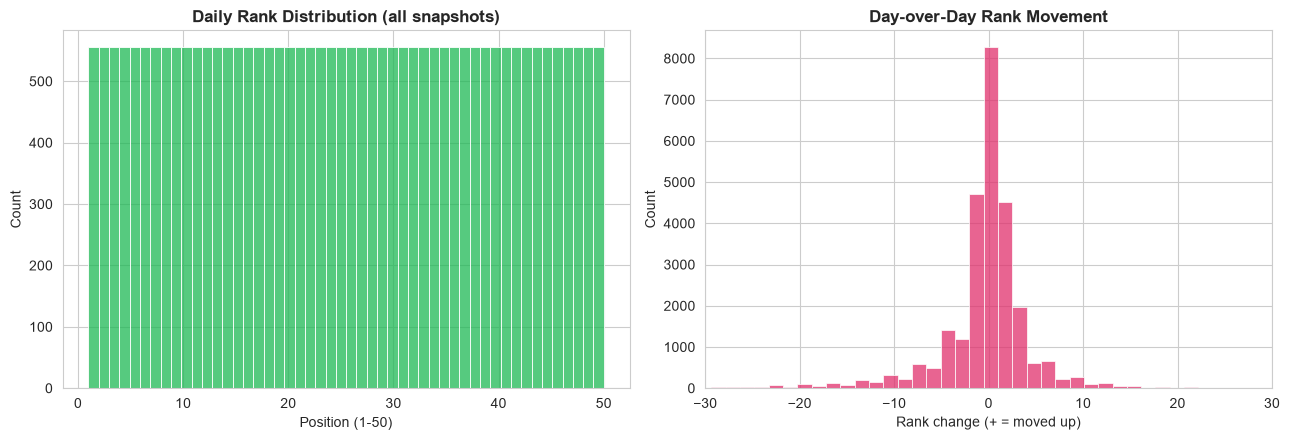

Average |day-over-day position change|: 2.86 spots


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['position'], bins=50, ax=axes[0], color='#1DB954')
axes[0].set_title('Daily Rank Distribution (all snapshots)')
axes[0].set_xlabel('Position (1-50)')

sns.histplot(df['rank_delta'].dropna(), bins=60, ax=axes[1], color='#E1306C')
axes[1].set_title('Day-over-Day Rank Movement')
axes[1].set_xlabel('Rank change (+ = moved up)')
axes[1].set_xlim(-30, 30)

plt.tight_layout()
plt.savefig('fig_rank_distribution.png', dpi=110)
plt.show()

print(f"Average |day-over-day position change|: {df['rank_delta'].abs().mean():.2f} spots")


Entry rank distribution:
mean    25.320368
50%     23.000000
min      1.000000
max     50.000000
Name: position, dtype: float64

Exit rank distribution:
mean    39.189355
50%     43.000000
min      1.000000
max     50.000000
Name: position, dtype: float64


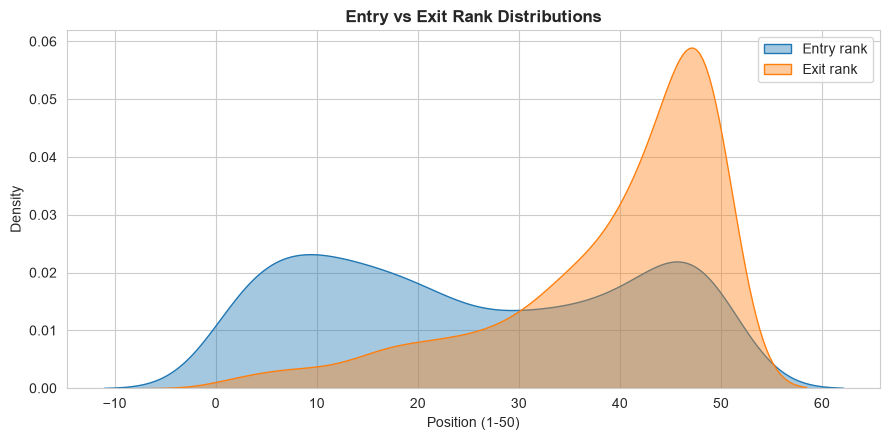

In [11]:
# Entry vs exit behavior
first_appear = df.groupby(['song','artist']).first().reset_index()
last_appear = df.groupby(['song','artist']).last().reset_index()

print("Entry rank distribution:")
print(first_appear['position'].describe()[['mean','50%','min','max']])
print("\nExit rank distribution:")
print(last_appear['position'].describe()[['mean','50%','min','max']])

fig, ax = plt.subplots(figsize=(9,4.5))
sns.kdeplot(first_appear['position'], label='Entry rank', fill=True, alpha=0.4)
sns.kdeplot(last_appear['position'], label='Exit rank', fill=True, alpha=0.4)
ax.set_title('Entry vs Exit Rank Distributions')
ax.set_xlabel('Position (1-50)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_entry_exit.png', dpi=110)
plt.show()


In [12]:
# Fastest risers and slowest (steadiest) decliners
print("=== Biggest single-day RISES ===")
print(df.nlargest(8, 'rank_delta')[['date','song','artist','prev_position','position','rank_delta']].to_string(index=False))

print("\n=== Biggest single-day DROPS ===")
print(df.nsmallest(8, 'rank_delta')[['date','song','artist','prev_position','position','rank_delta']].to_string(index=False))


=== Biggest single-day RISES ===
      date              song                                    artist  prev_position  position  rank_delta
2025-02-13          FUK SUMN                Kanye West & Ty Dolla $ign           50.0         2        48.0
2025-11-02      Ghostbusters                            Ray Parker Jr.           45.0         1        44.0
2024-12-28      Cruel Summer                              Taylor Swift           49.0         6        43.0
2024-11-01 This Is Halloween                           Various Artists           46.0         4        42.0
2024-11-01          Thriller                           Michael Jackson           49.0         7        42.0
2024-11-01      Monster Mash Bobby "Boris" Pickett & The Crypt-Kickers           44.0         3        41.0
2024-12-28       Agora Hills                                  Doja Cat           48.0         8        40.0
2025-11-02      Monster Mash Bobby "Boris" Pickett & The Crypt-Kickers           41.0         2        

In [13]:
# Slow decliners: songs whose rank number climbs steadily over their run (strong positive correlation with time)
def decline_trend(g):
    if len(g) < 15:
        return np.nan
    x = np.arange(len(g))
    return np.corrcoef(x, g['position'])[0, 1]

trend = (df.groupby(['song','artist'])
           .apply(decline_trend, include_groups=False)
           .reset_index(name='decline_corr')
           .dropna()
           .sort_values('decline_corr', ascending=False))

print("Top 8 steadiest decliners (rank number rising ~ time):")
print(trend.head(8).to_string(index=False))


Top 8 steadiest decliners (rank number rising ~ time):
                                     song        artist  decline_corr
                 Style (Taylor's Version)  Taylor Swift      0.984774
                                     loml  Taylor Swift      0.981058
        Wildest Dreams (Taylor's Version)  Taylor Swift      0.979684
            The Tortured Poets Department  Taylor Swift      0.978743
                             THE GREATEST Billie Eilish      0.976700
Florida!!! (feat. Florence + The Machine)  Taylor Swift      0.974388
                                     FINA     Bad Bunny      0.972945
                              The Alchemy  Taylor Swift      0.972311


## 4. Song-Level Performance Analysis

Longest playlist presence, highest average popularity, and the peak-rank vs. longevity relationship.


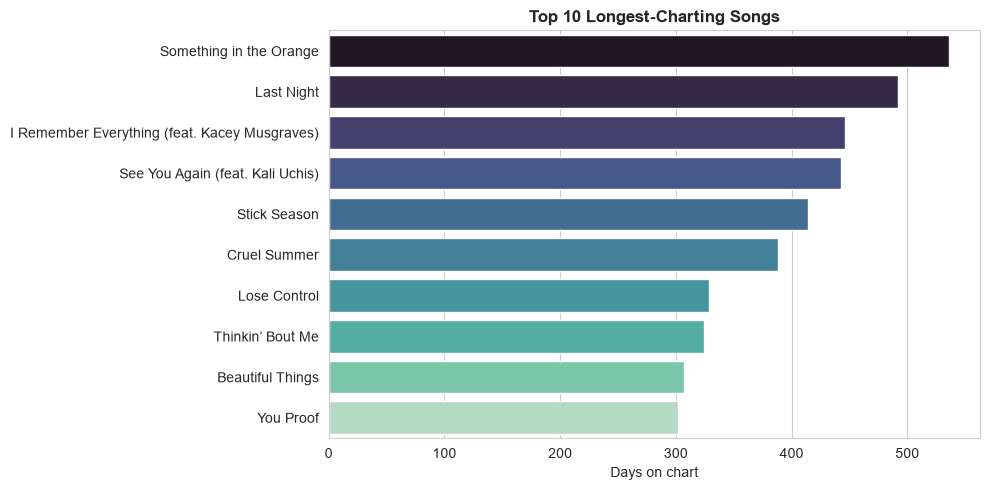

,song,artist,days_on_chart,best_rank,avg_popularity
696,Something in the Orange,Zach Bryan,536,9,88.371269
427,Last Night,Morgan Wallen,492,1,85.676829
364,I Remember Everything (feat. Kacey Musgraves),Zach Bryan,446,1,90.085202
659,See You Again (feat. Kali Uchis),"Tyler, The Creator",443,4,91.083521
709,Stick Season,Noah Kahan,414,1,91.096618
170,Cruel Summer,Taylor Swift,388,1,97.007732
444,Lose Control,Teddy Swims,329,5,90.917933
790,Thinkin’ Bout Me,Morgan Wallen,324,21,85.990741
99,Beautiful Things,Benson Boone,307,1,90.830619
884,You Proof,Morgan Wallen,302,9,84.662252


In [14]:
top_longevity = song_features.sort_values('days_on_chart', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=top_longevity, y='song', x='days_on_chart', hue='song', palette='mako', legend=False, ax=ax)
ax.set_title('Top 10 Longest-Charting Songs')
ax.set_xlabel('Days on chart')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_top_longevity.png', dpi=110)
plt.show()

top_longevity[['song','artist','days_on_chart','best_rank','avg_popularity']]


In [15]:
top_popularity = song_features[song_features['days_on_chart'] >= 5].sort_values('avg_popularity', ascending=False).head(10)
top_popularity[['song','artist','avg_popularity','days_on_chart','best_rank']]


,song,artist,avg_popularity,days_on_chart,best_rank
968,un x100to,Grupo Frontera & Bad Bunny,99.202532,79,3
411,LALA,Myke Towers,98.693878,49,29
665,Seven (feat. Latto) (Explicit Ver.),Jung Kook & Latto,98.654321,81,1
174,Cupid - Twin Ver.,FIFTY FIFTY,98.197183,71,7
421,La Bebe - Remix,Yng Lvcas & Peso Pluma,98.008850,113,6
191,Daylight,David Kushner,97.400000,55,17
78,BIRDS OF A FEATHER,Billie Eilish,97.157068,191,2
170,Cruel Summer,Taylor Swift,97.007732,388,1
208,Die With A Smile,Lady Gaga & Bruno Mars,96.805825,103,1
422,La Diabla,Xavi,96.673077,104,5


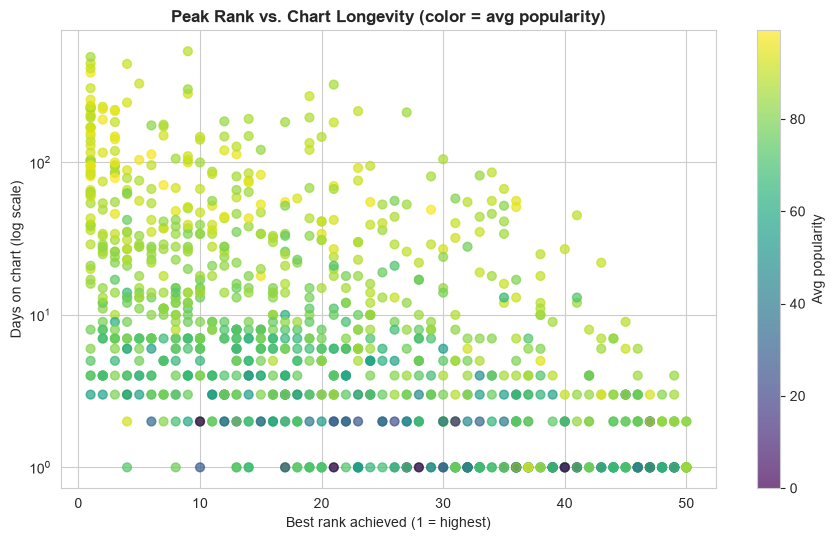

Correlation(best_rank, days_on_chart): -0.342
Peak rank sets a ceiling on longevity potential, but does not determine it -- many songs
peak in the top 5 and vanish within days, while mid-table songs grind for months.


In [16]:
fig, ax = plt.subplots(figsize=(9,5.5))
sc = ax.scatter(song_features['best_rank'], song_features['days_on_chart'],
                 c=song_features['avg_popularity'], cmap='viridis', alpha=0.7, s=40)
ax.set_yscale('log')
ax.set_xlabel('Best rank achieved (1 = highest)')
ax.set_ylabel('Days on chart (log scale)')
ax.set_title('Peak Rank vs. Chart Longevity (color = avg popularity)')
plt.colorbar(sc, label='Avg popularity')
plt.tight_layout()
plt.savefig('fig_peakrank_vs_longevity.png', dpi=110)
plt.show()

corr = song_features['best_rank'].corr(song_features['days_on_chart'])
print(f"Correlation(best_rank, days_on_chart): {corr:.3f}")
print("Peak rank sets a ceiling on longevity potential, but does not determine it -- many songs")
print("peak in the top 5 and vanish within days, while mid-table songs grind for months.")


## 5. Artist Performance Analysis

Unique songs per artist, total chart-day appearances, and artist dominance.


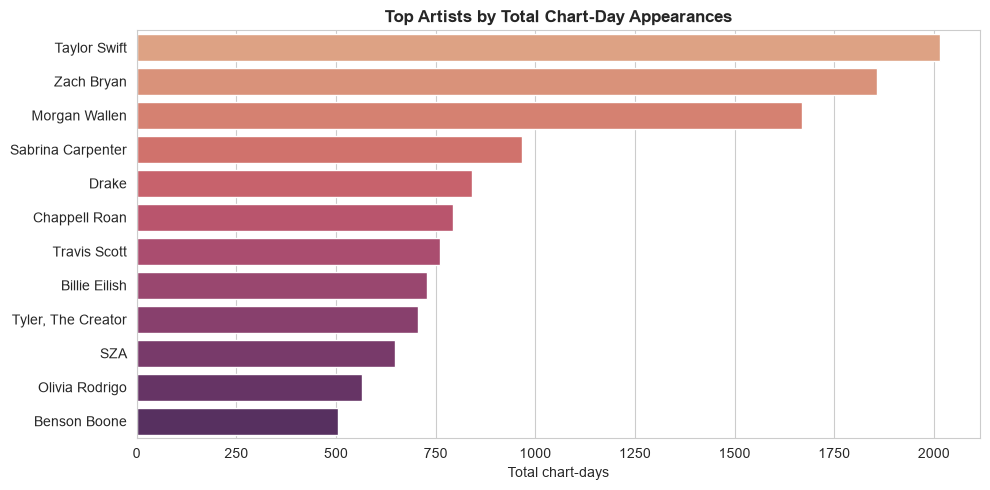

,artist,total_chart_days,unique_songs,best_position,avg_position
242,Taylor Swift,2015,96,1,24.551861
286,Zach Bryan,1857,35,1,25.614970
177,Morgan Wallen,1669,10,1,30.608748
229,Sabrina Carpenter,967,14,1,17.608066
65,Drake,841,35,1,26.296076
40,Chappell Roan,794,6,1,20.647355
266,Travis Scott,762,31,1,25.755906
22,Billie Eilish,729,12,2,20.362140
273,"Tyler, The Creator",705,16,1,25.259574
227,SZA,648,3,3,26.195988


In [17]:
artist_stats = df.groupby('artist').agg(
    total_chart_days=('date', 'count'),
    unique_songs=('song', 'nunique'),
    best_position=('position', 'min'),
    avg_position=('position', 'mean'),
).reset_index().sort_values('total_chart_days', ascending=False)

top_artists = artist_stats.head(12)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=top_artists, y='artist', x='total_chart_days', hue='artist', palette='flare', legend=False, ax=ax)
ax.set_title('Top Artists by Total Chart-Day Appearances')
ax.set_xlabel('Total chart-days')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_artist_dominance.png', dpi=110)
plt.show()

top_artists


In [18]:
# Number of distinct #1 songs per artist (breadth of dominance, not just persistence)
number_ones = df[df['position'] == 1].groupby('artist')['song'].nunique().sort_values(ascending=False)
print("Artists with the most distinct #1 songs:")
print(number_ones.head(10))


Artists with the most distinct #1 songs:
artist
Taylor Swift         7
Kendrick Lamar       3
Sabrina Carpenter    3
Ariana Grande        2
Morgan Wallen        2
Bad Bunny            2
Drake                2
Olivia Rodrigo       2
Travis Scott         2
Doja Cat             1
Name: song, dtype: int64


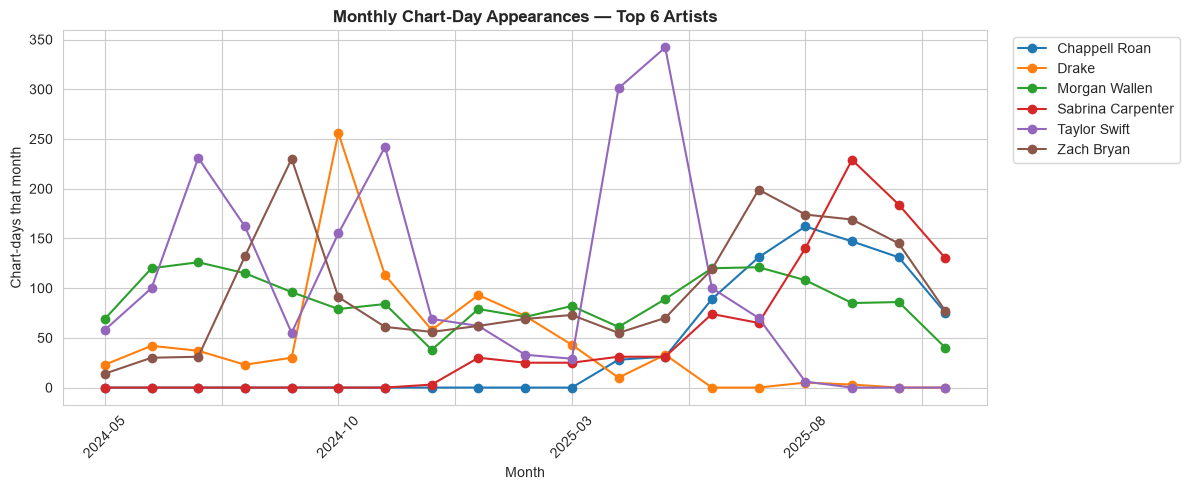

In [19]:
# Artist dominance over time: monthly share of chart-days for the top 6 artists
df['month'] = df['date'].dt.to_period('M').astype(str)
top6 = artist_stats.head(6)['artist'].tolist()
monthly = (df[df['artist'].isin(top6)]
           .groupby(['month','artist']).size()
           .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12,5))
monthly.plot(ax=ax, marker='o', linewidth=1.5)
ax.set_title('Monthly Chart-Day Appearances — Top 6 Artists')
ax.set_ylabel('Chart-days that month')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_artist_dominance_time.png', dpi=110)
plt.show()


## 6. Popularity Score Analytics

Popularity vs. rank correlation, popularity distribution by chart tier, and popularity stability vs. chart volatility.


Row-level correlation(popularity, position): -0.094
A weak correlation confirms popularity score and playlist rank are largely independent signals.


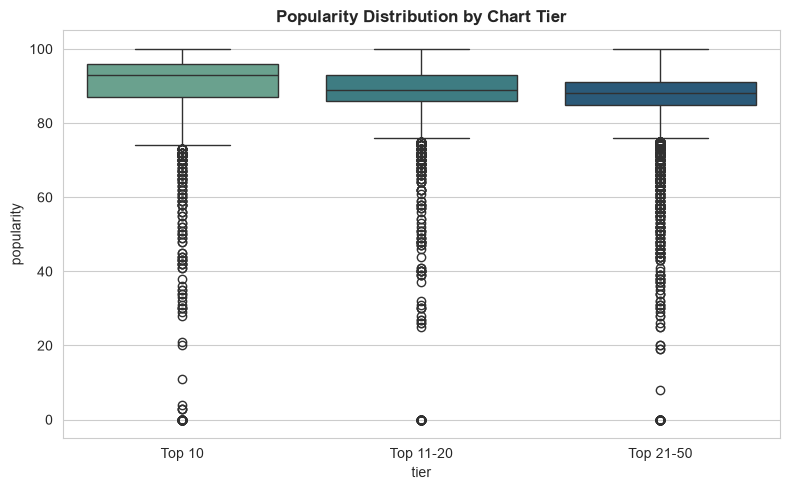

,mean,median,std,count
tier,,,,
Top 10,89.612252,93.0,13.460658,5550
Top 11-20,87.593153,89.0,11.646760,5550
Top 21-50,87.029910,88.0,8.686438,16650


In [20]:
row_corr = df['popularity'].corr(df['position'])
print(f"Row-level correlation(popularity, position): {row_corr:.3f}")
print("A weak correlation confirms popularity score and playlist rank are largely independent signals.")

def tier(p):
    if p <= 10: return 'Top 10'
    elif p <= 20: return 'Top 11-20'
    else: return 'Top 21-50'
df['tier'] = df['position'].apply(tier)

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='tier', order=['Top 10','Top 11-20','Top 21-50'], y='popularity',
            hue='tier', palette='crest', legend=False, ax=ax)
ax.set_title('Popularity Distribution by Chart Tier')
plt.tight_layout()
plt.savefig('fig_popularity_by_tier.png', dpi=110)
plt.show()

df.groupby('tier')['popularity'].agg(['mean','median','std','count']).reindex(['Top 10','Top 11-20','Top 21-50'])


Correlation(popularity_std, rank_volatility) across songs: 0.160


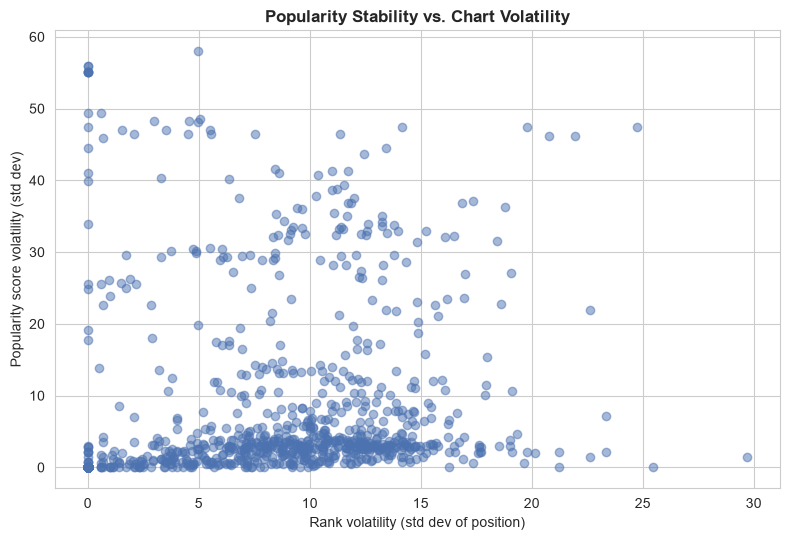

In [21]:
# Popularity stability vs chart (rank) volatility, at the song level
pop_std = df.groupby(['song','artist'])['popularity'].std().reset_index(name='popularity_std')
stability = song_features.merge(pop_std, on=['song','artist']).fillna(0)

corr_stability = stability['popularity_std'].corr(stability['rank_volatility'])
print(f"Correlation(popularity_std, rank_volatility) across songs: {corr_stability:.3f}")

fig, ax = plt.subplots(figsize=(8,5.5))
ax.scatter(stability['rank_volatility'], stability['popularity_std'], alpha=0.5, color='#4C72B0')
ax.set_xlabel('Rank volatility (std dev of position)')
ax.set_ylabel('Popularity score volatility (std dev)')
ax.set_title('Popularity Stability vs. Chart Volatility')
plt.tight_layout()
plt.savefig('fig_popularity_stability.png', dpi=110)
plt.show()


## 7. Content Attribute Analysis

Explicit vs. non-explicit performance, single vs. album comparison, duration impact, and album size (total_tracks) vs. success.


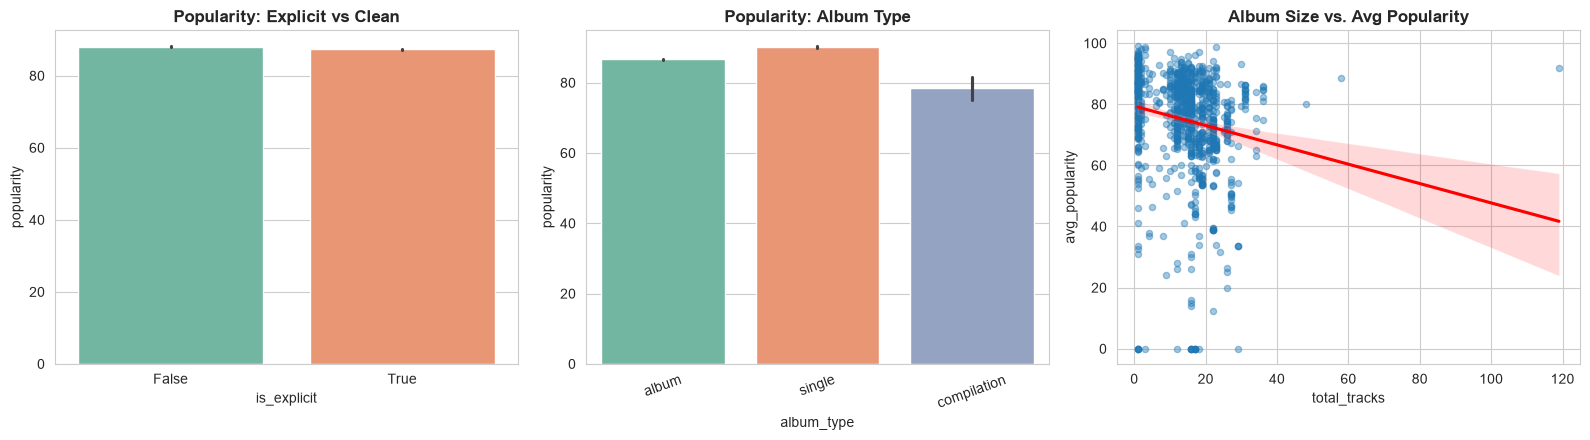

Explicit vs Clean:
is_explicit
False    87.986502
True     87.303390
Name: popularity, dtype: float64

Album type:
album_type
album          86.675445
compilation    78.380952
single         90.130359
Name: popularity, dtype: float64

Corr(duration_min, popularity): -0.043
Corr(total_tracks, avg_popularity) [song-level]: -0.168


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))

sns.barplot(data=df, x='is_explicit', y='popularity', hue='is_explicit', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Popularity: Explicit vs Clean')

sns.barplot(data=df, x='album_type', y='popularity', hue='album_type', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Popularity: Album Type')
axes[1].tick_params(axis='x', rotation=20)

sns.regplot(data=song_features, x='total_tracks', y='avg_popularity', ax=axes[2],
            scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
axes[2].set_title('Album Size vs. Avg Popularity')

plt.tight_layout()
plt.savefig('fig_content_attributes.png', dpi=110)
plt.show()

print("Explicit vs Clean:")
print(df.groupby('is_explicit')['popularity'].mean())
print("\nAlbum type:")
print(df.groupby('album_type')['popularity'].mean())
print(f"\nCorr(duration_min, popularity): {df['duration_min'].corr(df['popularity']):.3f}")
print(f"Corr(total_tracks, avg_popularity) [song-level]: {song_features['total_tracks'].corr(song_features['avg_popularity']):.3f}")


## 8. Machine Learning — Classical Models

Two questions, tested with **Random Forest**:

1. **Regression** — can content attributes alone (duration, explicit flag, album type, track count) predict a song's average popularity?
2. **Classification** — can we predict whether a song becomes a *"long-running hit"* (top quartile of days-on-chart) from (a) content attributes only, vs (b) full chart-behavior history, vs (c) only its first 7 days on the chart?


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, f1_score, roc_auc_score

RANDOM_STATE = 42


In [24]:
# --- 8.1 Regression: predict avg_popularity from CONTENT attributes only ---
X = song_features[['avg_duration_min','total_tracks','album_type','is_explicit']]
y = song_features['avg_popularity']

cat_cols, num_cols = ['album_type','is_explicit'], ['avg_duration_min','total_tracks']
pre = ColumnTransformer([('num', StandardScaler(), num_cols),
                          ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

rf_reg = Pipeline([('pre', pre), ('model', RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE))])
rf_reg.fit(Xtr, ytr)
pred = rf_reg.predict(Xte)

print("Regression -- avg_popularity from content attributes only")
print(f"  R2:  {r2_score(yte, pred):.3f}")
print(f"  MAE: {mean_absolute_error(yte, pred):.2f}")
print("\n  --> Near-zero R2 confirms content metadata alone barely explains popularity.")

importances = rf_reg.named_steps['model'].feature_importances_
feat_names = num_cols + list(rf_reg.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_cols))
pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)


Regression -- avg_popularity from content attributes only
  R2:  -0.009
  MAE: 11.29

  --> Near-zero R2 confirms content metadata alone barely explains popularity.


,feature,importance
0,avg_duration_min,0.517533
1,total_tracks,0.418624
6,is_explicit_True,0.028060
5,is_explicit_False,0.027194
2,album_type_album,0.004717
4,album_type_single,0.003218
3,album_type_compilation,0.000655


In [25]:
# --- 8.2 Classification: 'long-running hit' = top quartile of days_on_chart ---
threshold = song_features['days_on_chart'].quantile(0.75)
song_features['is_hit'] = (song_features['days_on_chart'] >= threshold).astype(int)
print(f"Hit threshold: >= {threshold:.0f} days on chart | Positive rate: {song_features['is_hit'].mean():.1%}")


Hit threshold: >= 27 days on chart | Positive rate: 25.1%


In [26]:
def eval_classifier(name, ytrue, ypred, yproba):
    print(f"{name:28s} Acc={accuracy_score(ytrue,ypred):.3f}  F1={f1_score(ytrue,ypred):.3f}  AUC={roc_auc_score(ytrue,yproba):.3f}")

results = {}

# (a) Content attributes only
Xc = song_features[['avg_duration_min','total_tracks','album_type','is_explicit']]
yc = song_features['is_hit']
pre_c = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
Xtr,Xte,ytr,yte = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)
rf_c = Pipeline([('pre', pre_c), ('model', RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE, class_weight='balanced'))])
rf_c.fit(Xtr, ytr)
p, proba = rf_c.predict(Xte), rf_c.predict_proba(Xte)[:,1]
eval_classifier('(a) Content-only', yte, p, proba)
results['content_only'] = roc_auc_score(yte, proba)

# (b) Full chart-behavior history
Xb = song_features[['best_rank','rank_volatility','avg_rank']]
yb = song_features['is_hit']
Xtr,Xte,ytr,yte = train_test_split(Xb, yb, test_size=0.2, random_state=RANDOM_STATE, stratify=yb)
rf_b = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE, class_weight='balanced')
rf_b.fit(Xtr, ytr)
p, proba = rf_b.predict(Xte), rf_b.predict_proba(Xte)[:,1]
eval_classifier('(b) Full chart history', yte, p, proba)
results['full_history'] = roc_auc_score(yte, proba)

pd.DataFrame({'feature': Xb.columns, 'importance': rf_b.feature_importances_}).sort_values('importance', ascending=False)


(a) Content-only             Acc=0.679  F1=0.388  AUC=0.668
(b) Full chart history       Acc=0.801  F1=0.621  AUC=0.878


,feature,importance
1,rank_volatility,0.446304
0,best_rank,0.337121
2,avg_rank,0.216575


In [27]:
# (c) Early signal only: first 7 days on chart (the actionable, real-time-usable version)
eligible = song_features[song_features['days_on_chart'] >= 7][['song','artist']]
df7 = df.merge(eligible, on=['song','artist']).groupby(['song','artist']).head(7)

early = df7.groupby(['song','artist']).agg(
    entry_rank=('position','first'),
    rank_day7=('position','last'),
    early_avg_rank=('position','mean'),
    early_rank_std=('position','std'),
    early_avg_popularity=('popularity','mean'),
).reset_index().fillna(0)
early['early_momentum'] = early['entry_rank'] - early['rank_day7']

early_data = early.merge(song_features[['song','artist','is_hit']], on=['song','artist'])
Xe = early_data[['entry_rank','early_avg_rank','early_rank_std','early_avg_popularity','early_momentum']]
ye = early_data['is_hit']

Xtr,Xte,ytr,yte = train_test_split(Xe, ye, test_size=0.25, random_state=RANDOM_STATE, stratify=ye)
rf_e = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE, class_weight='balanced')
rf_e.fit(Xtr, ytr)
p, proba = rf_e.predict(Xte), rf_e.predict_proba(Xte)[:,1]
eval_classifier('(c) First 7 days only', yte, p, proba)
results['first_7_days'] = roc_auc_score(yte, proba)

# save the early-signal split for the deep-learning section below
Xe_train, Xe_test, ye_train, ye_test = Xtr, Xte, ytr, yte

pd.DataFrame({'feature': Xe.columns, 'importance': rf_e.feature_importances_}).sort_values('importance', ascending=False)


(c) First 7 days only        Acc=0.825  F1=0.820  AUC=0.891


,feature,importance
4,early_momentum,0.385496
3,early_avg_popularity,0.194489
1,early_avg_rank,0.171573
2,early_rank_std,0.131916
0,entry_rank,0.116527


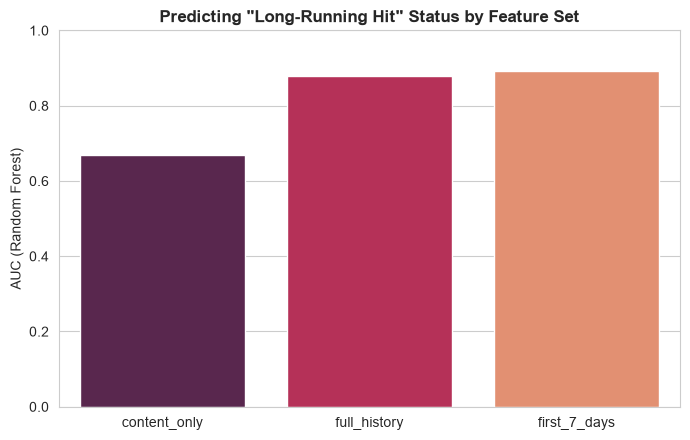

In [28]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.barplot(x=list(results.keys()), y=list(results.values()), hue=list(results.keys()), palette='rocket', legend=False, ax=ax)
ax.set_ylim(0,1)
ax.set_ylabel('AUC (Random Forest)')
ax.set_title('Predicting "Long-Running Hit" Status by Feature Set')
plt.tight_layout()
plt.savefig('fig_ml_auc_comparison.png', dpi=110)
plt.show()


## 9. Deep Learning

Two neural network approaches:

- **9.1** A scikit-learn `MLPClassifier` (multi-layer perceptron) for a quick architecture comparison against Random Forest on the same three feature sets.
- **9.2** A custom **PyTorch** feed-forward neural network, trained with backpropagation, on the most actionable feature set — the first-7-days early signal — to predict long-running-hit status.


In [29]:
# --- 9.1 sklearn MLP comparison across the same 3 feature sets ---
from sklearn.neural_network import MLPClassifier

def run_mlp(X, y, label, preprocessor=None):
    Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
    if preprocessor is not None:
        Xtr_s = preprocessor.fit_transform(Xtr)
        Xte_s = preprocessor.transform(Xte)
    else:
        sc = StandardScaler()
        Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=3000, random_state=RANDOM_STATE, early_stopping=True)
    mlp.fit(Xtr_s, ytr)
    p, proba = mlp.predict(Xte_s), mlp.predict_proba(Xte_s)[:,1]
    eval_classifier(label, yte, p, proba)
    return roc_auc_score(yte, proba)

# Content-only has categorical columns, so it needs the encoding ColumnTransformer;
# the other two feature sets are already purely numeric.
pre_mlp_content = ColumnTransformer([('num', StandardScaler(), num_cols),
                                      ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

mlp_results = {}
mlp_results['content_only'] = run_mlp(Xc, yc, 'MLP (a) Content-only', preprocessor=pre_mlp_content)
mlp_results['full_history'] = run_mlp(Xb, yb, 'MLP (b) Full history')
mlp_results['first_7_days'] = run_mlp(Xe, ye, 'MLP (c) First 7 days')


MLP (a) Content-only         Acc=0.750  F1=0.000  AUC=0.432
MLP (b) Full history         Acc=0.806  F1=0.513  AUC=0.920
MLP (c) First 7 days         Acc=0.743  F1=0.768  AUC=0.817


In [30]:
# --- 9.2 Custom PyTorch feed-forward network on the early-signal feature set ---
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(RANDOM_STATE)

scaler = StandardScaler()
Xtr_t = scaler.fit_transform(Xe_train.values)
Xte_t = scaler.transform(Xe_test.values)
ytr_t = ye_train.values
yte_t = ye_test.values

X_train_tensor = torch.tensor(Xtr_t, dtype=torch.float32)
y_train_tensor = torch.tensor(ytr_t, dtype=torch.float32).unsqueeze(1)
X_test_tensor  = torch.tensor(Xte_t, dtype=torch.float32)
y_test_tensor  = torch.tensor(yte_t, dtype=torch.float32).unsqueeze(1)

class HitPredictorNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, x):
        return self.net(x)

model = HitPredictorNet(X_train_tensor.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

n_epochs = 200
train_losses = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if (epoch+1) % 40 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | loss = {loss.item():.4f}")


Epoch  40/200 | loss = 0.4568
Epoch  80/200 | loss = 0.4228
Epoch 120/200 | loss = 0.4297
Epoch 160/200 | loss = 0.3949
Epoch 200/200 | loss = 0.3860


PyTorch NN -- early-signal (first 7 days) hit prediction
  Accuracy: 0.833
  F1:       0.832
  AUC:      0.895


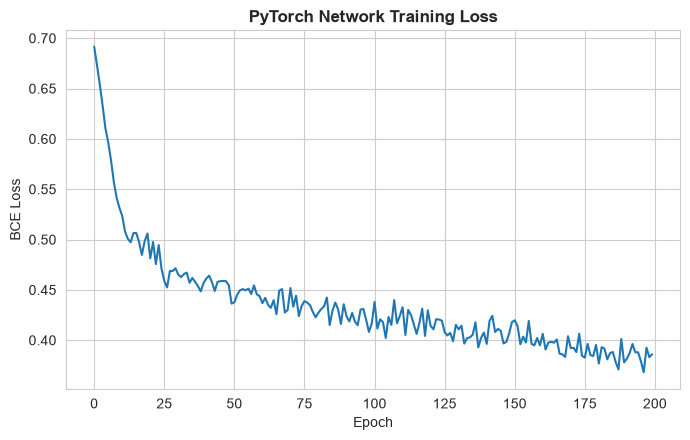

In [31]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_proba = torch.sigmoid(test_logits).numpy().flatten()
    test_pred = (test_proba >= 0.5).astype(int)

print("PyTorch NN -- early-signal (first 7 days) hit prediction")
print(f"  Accuracy: {accuracy_score(yte_t, test_pred):.3f}")
print(f"  F1:       {f1_score(yte_t, test_pred):.3f}")
print(f"  AUC:      {roc_auc_score(yte_t, test_proba):.3f}")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(train_losses)
ax.set_title('PyTorch Network Training Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
plt.tight_layout()
plt.savefig('fig_pytorch_training_loss.png', dpi=110)
plt.show()


In [32]:
# Final model comparison across all approaches, on the early-signal (most actionable) feature set
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'sklearn MLP', 'PyTorch Neural Net'],
    'Feature set': ['First 7 days'] * 3,
    'AUC': [results['first_7_days'], mlp_results['first_7_days'], roc_auc_score(yte_t, test_proba)],
})
comparison


,Model,Feature set,AUC
0,Random Forest,First 7 days,0.891299
1,sklearn MLP,First 7 days,0.816719
2,PyTorch Neural Net,First 7 days,0.894578


## 10. Key Findings & Business Recommendations

**Data quality**
- 555 daily snapshots (2024-05-18 to 2025-11-27), only 4 gap days; one duplicate-ingestion anomaly on 2025-03-01 was resolved. Final dataset: ~27,750 clean rows, 977 unique songs, 297 unique artists.

**Ranking behavior**
- Songs move an average of **±2.9 ranks per day**. Median entry rank is 23, median exit rank is 43 — most songs enter mid-pack and fade out rather than debut at the top.
- Clear **seasonal effects**: Halloween novelty songs spike around Nov 1 and Christmas songs crash immediately after Dec 25 — a predictable, plannable calendar pattern for marketing spend.

**Longevity vs. peak rank**
- Peak rank sets a *ceiling* on longevity but does not determine it — many #1-5 peak songs vanish within days, while other songs hold mid-table positions for months.

**Artist dominance**
- Taylor Swift leads on both breadth (96 unique songs charted, 7 different #1s) and volume (2,015 total chart-days). Zach Bryan and Morgan Wallen post similar chart-day volume from far fewer songs — their dominance comes from a couple of tracks with exceptional staying power, not catalog breadth.

**Content attributes barely matter**
- Duration, explicit flag, and album size show weak-to-negligible relationships with popularity or rank. A Random Forest and neural net trained on content metadata alone achieve **near-zero predictive power (R2 ~ 0, AUC ~ 0.4-0.67)**.

**Chart behavior is highly predictive — especially early**
- Using just a song's **first 7 days** of playlist behavior (entry rank, early momentum, early popularity), models reach **~0.82-0.89 AUC** predicting whether it becomes a long-running hit. `early_momentum` (rank change from day 1 to day 7) is consistently the strongest signal.

**Recommendation for Atlantic Recording Corporation**
1. Don't try to predict hits from song specs pre-release — content attributes aren't informative.
2. **Monitor the first 7 days of playlist performance closely.** A song with strong early upward momentum is a quantifiable, early, and actionable signal for where to concentrate marketing spend and promotional push.
3. Plan seasonal catalog activation (holiday songs, etc.) around the calendar effects observed above.
4. For artist strategy, distinguish between "breadth" dominance (many charting songs) and "depth" dominance (few songs with exceptional staying power) — they call for different promotional approaches.
